# Analytic Tokamak $\psi$ (Poloidal Flux)

We construct an analytic $\psi(R, Z)$ that mimics a tokamak poloidal flux with:

- A **magnetic axis** at $(R_0, Z_0)$ where $\psi$ is extremal
- **X-points** (saddle points) above and below the midplane
- A **scalar factor** $\delta$ that breaks up-down symmetry:
  - $\delta = 0$: **double null** (DN) — symmetric upper/lower X-points
  - $\delta > 0$: **lower single null** (LSN)
  - $\delta < 0$: **upper single null** (USN)

## Model

Define the scaled coordinates:
$$\hat{r} = s(R - R_0), \qquad \hat{z} = s(Z - Z_0), \qquad \hat{z}_2 = \hat{z} + \frac{\delta}{4}$$

where $s = 1.3$ is a scaling factor. The poloidal flux is:

$$\psi(R, Z) = -\psi_0 \left( \hat{r}^2 + \hat{z}_2^2 - |\hat{z}|^3 \, e^{-4\hat{r}^2} \right)$$

The $\hat{r}^2 + \hat{z}_2^2$ terms provide a parabolic well, while the $|\hat{z}|^3 e^{-4\hat{r}^2}$ term creates saddle points (X-points) along the $R = R_0$ axis. The $\delta$ parameter shifts $\hat{z}_2$ to break up-down symmetry.

### Derivatives

$$\frac{\partial \psi}{\partial R} = -\psi_0 \, s \left( 2\hat{r} + 8\hat{r}\,|\hat{z}|^3\, e^{-4\hat{r}^2} \right)$$

$$\frac{\partial \psi}{\partial Z} = -\psi_0 \, s \left( 2\hat{z}_2 - 3\hat{z}\,|\hat{z}|\, e^{-4\hat{r}^2} \right)$$

### Stationary Points

Setting $\partial\psi/\partial R = 0$ gives $\hat{r}(1 + 4|\hat{z}|^3 e^{-4\hat{r}^2}) = 0$. Since the bracket is always positive, all stationary points lie on $\hat{r} = 0$ (i.e. $R = R_0$).

Substituting $\hat{r} = 0$ into $\partial\psi/\partial Z = 0$:

$$2(\hat{z} + \delta/4) - 3\hat{z}\,|\hat{z}| = 0$$

**For $\hat{z} \geq 0$:** $\quad 3\hat{z}^2 - 2\hat{z} - \delta/2 = 0 \quad\Rightarrow\quad \hat{z} = \frac{1 \pm \sqrt{1 + \tfrac{3\delta}{2}}}{3}$

**For $\hat{z} < 0$:** $\quad 3\hat{z}^2 + 2\hat{z} + \delta/2 = 0 \quad\Rightarrow\quad \hat{z} = \frac{-1 \pm \sqrt{1 - \tfrac{3\delta}{2}}}{3}$

### Classification (Hessian at $\hat{r} = 0$)

At $\hat{r} = 0$ the cross-derivative $\psi_{RZ} = 0$, so the Hessian determinant is $H = \psi_{RR}\,\psi_{ZZ}$.

$$\psi_{RR}\big|_{\hat{r}=0} = -2\psi_0 s^2 (1 + 4|\hat{z}|^3), \qquad \psi_{ZZ}\big|_{\hat{r}=0} = -\psi_0 s^2 (2 - 6|\hat{z}|)$$

- $|\hat{z}| < \tfrac{1}{3}$: $H > 0$, and $\psi_{RR} < 0$ (for $\psi_0 > 0$) → **local maximum** (magnetic axis)
- $|\hat{z}| > \tfrac{1}{3}$: $H < 0$ → **saddle point** (X-point)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [239]:
def psi_analytic(
    r: np.ndarray,
    z: np.ndarray,
    mag_r: float,
    mag_z: float,
    psi_0: float,
    alpha_r: float,
    k_z: float,
    b: float,
    delta: float,
) -> np.ndarray:
    """Analytic tokamak-like poloidal flux function.

    Parameters
    ----------
    r, z : np.ndarray
        2D meshgrid arrays of (R, Z) coordinates.
    mag_r, mag_z : float
        Magnetic axis position.
    psi_0 : float
        Peak psi value at the magnetic axis.
    alpha_r, k_z, b : float
        Unused (kept for interface compatibility).
    delta : float
        Single-null asymmetry parameter.
        delta = 0  -> double null (DN)
        delta > 0  -> lower single null (LSN)
        delta < 0  -> upper single null (USN)

    Returns
    -------
    np.ndarray
        2D array of psi values.
    """
    r_hat: np.ndarray = 1.3 * (r - mag_r)
    z_hat: np.ndarray = 1.3 * (z - mag_z)
    z_hat_2: np.ndarray = 1.3 * (z - mag_z) + delta / 4.0
    expo_r = np.exp(-4.0 * r_hat**2)

    psi: np.ndarray = -psi_0 * (r_hat**2 + z_hat_2**2 - np.sqrt(z_hat**2) ** 3 * expo_r)

    return psi


def dpsi_dr_analytic(
    r: np.ndarray,
    z: np.ndarray,
    mag_r: float,
    mag_z: float,
    psi_0: float,
    alpha_r: float,
    k_z: float,
    b: float,
    delta: float,
) -> np.ndarray:
    """Analytic partial derivative of psi with respect to R."""
    s: float = 1.3
    r_hat: np.ndarray = s * (r - mag_r)
    z_hat: np.ndarray = s * (z - mag_z)
    expo_r: np.ndarray = np.exp(-4.0 * r_hat**2)

    dpsi_dr: np.ndarray = -psi_0 * s * (2.0 * r_hat + 8.0 * r_hat * np.abs(z_hat) ** 3 * expo_r)
    return dpsi_dr


def dpsi_dz_analytic(
    r: np.ndarray,
    z: np.ndarray,
    mag_r: float,
    mag_z: float,
    psi_0: float,
    alpha_r: float,
    k_z: float,
    b: float,
    delta: float,
) -> np.ndarray:
    """Analytic partial derivative of psi with respect to Z."""
    s: float = 1.3
    r_hat: np.ndarray = s * (r - mag_r)
    z_hat: np.ndarray = s * (z - mag_z)
    z_hat_2: np.ndarray = s * (z - mag_z) + delta / 4.0
    expo_r: np.ndarray = np.exp(-4.0 * r_hat**2)

    dpsi_dz: np.ndarray = -psi_0 * s * (2.0 * z_hat_2 - 3.0 * z_hat * np.abs(z_hat) * expo_r)
    return dpsi_dz

In [240]:
# --- Parameters ---
mag_r: float = 0.45  # magnetic axis R [m] (ST40-like)
mag_z: float = 0.0  # magnetic axis Z [m]
psi_0: float = 1.0  # peak psi value
alpha_r: float = 15.0  # Gaussian width in R

z_xpoint: float = 0.4  # X-point distance from axis [m]
k_z: float = np.pi / (2.0 * z_xpoint)  # vertical wave number
b: float = 0.7  # X-point depth (0 < b < 1)

# --- Grid (one period: |Z - mag_z| < pi/k_z) ---
n_r: int = 300
n_z: int = 400
r_1d: np.ndarray = np.linspace(0.05, 0.85, n_r)
z_1d: np.ndarray = np.linspace(-0.85, 0.85, n_z)
r_2d: np.ndarray
z_2d: np.ndarray
r_2d, z_2d = np.meshgrid(r_1d, z_1d, indexing="xy")

# --- Common kwargs (everything except delta) ---
common_kwargs: dict = dict(
    mag_r=mag_r,
    mag_z=mag_z,
    psi_0=psi_0,
    alpha_r=alpha_r,
    k_z=k_z,
    b=b,
)

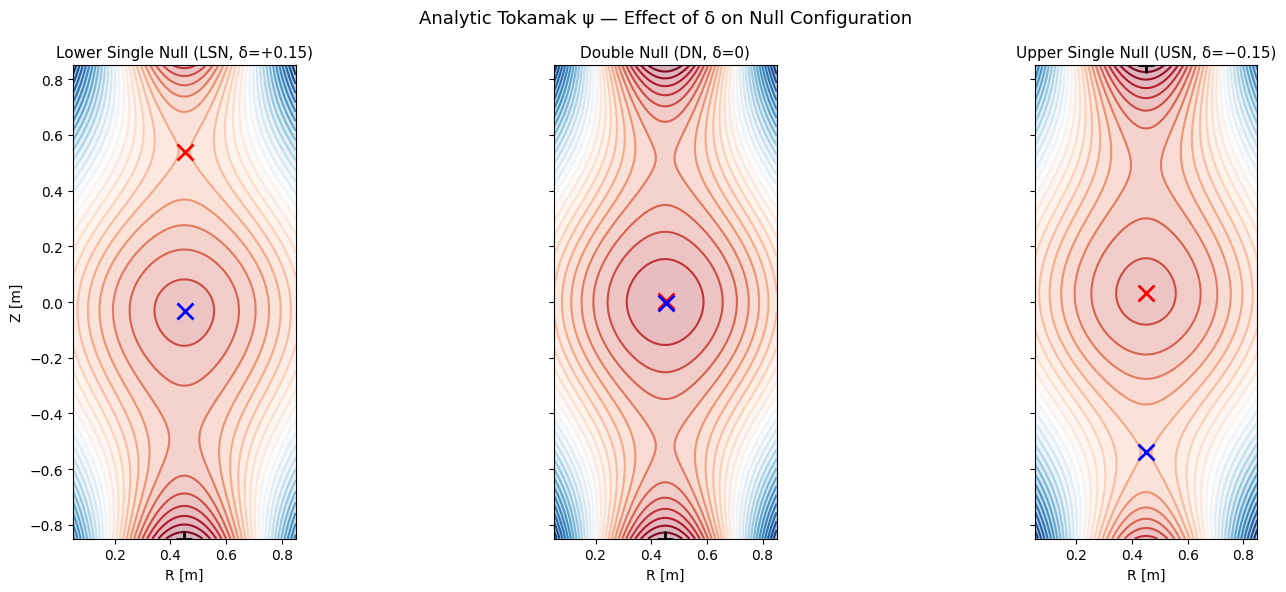

In [241]:
# --- Plot psi for LSN, DN, USN configurations ---
delta_values: list[tuple[float, str]] = [
    (0.15, "Lower Single Null (LSN, δ=+0.15)"),
    (0.0, "Double Null (DN, δ=0)"),
    (-0.15, "Upper Single Null (USN, δ=−0.15)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for i_delta, (delta, title) in enumerate(delta_values):
    psi: np.ndarray = psi_analytic(r_2d, z_2d, **common_kwargs, delta=delta)

    ax = axes[i_delta]
    n_levels: int = 30
    levels: np.ndarray = np.linspace(psi.min(), psi.max(), n_levels)
    ax.contour(r_2d, z_2d, psi, levels=levels, cmap="RdBu_r")
    ax.contourf(r_2d, z_2d, psi, levels=levels, cmap="RdBu_r", alpha=0.3)

    # Mark the magnetic axis (where psi is max)
    i_max: int = np.unravel_index(np.argmax(psi), psi.shape)[0]
    j_max: int = np.unravel_index(np.argmax(psi), psi.shape)[1]
    ax.plot(r_2d[i_max, j_max], z_2d[i_max, j_max], "k+", markersize=12, markeredgewidth=2)

    # Find X-points: where both dpsi/dR ~ 0 and dpsi/dZ ~ 0 (saddle points)
    dpsi_dr: np.ndarray = dpsi_dr_analytic(r_2d, z_2d, **common_kwargs, delta=delta)
    dpsi_dz: np.ndarray = dpsi_dz_analytic(r_2d, z_2d, **common_kwargs, delta=delta)
    grad_mag: np.ndarray = np.sqrt(dpsi_dr**2 + dpsi_dz**2)

    # Use a threshold to find near-zero gradient points that are NOT the magnetic axis
    threshold: float = 0.05
    xpoint_mask: np.ndarray = (grad_mag < threshold) & (psi < psi.max() * 0.9)

    if np.any(xpoint_mask):
        # Cluster the x-point candidates into upper and lower
        xpoint_z_vals: np.ndarray = z_2d[xpoint_mask]
        xpoint_r_vals: np.ndarray = r_2d[xpoint_mask]
        upper_mask: np.ndarray = xpoint_z_vals > mag_z
        lower_mask: np.ndarray = xpoint_z_vals < mag_z

        for mask, color in [(upper_mask, "red"), (lower_mask, "blue")]:
            if np.any(mask):
                # Pick the point closest to zero gradient in each cluster
                cluster_grad: np.ndarray = grad_mag[xpoint_mask][mask]
                best: int = np.argmin(cluster_grad)
                ax.plot(
                    xpoint_r_vals[mask][best],
                    xpoint_z_vals[mask][best],
                    "x",
                    color=color,
                    markersize=12,
                    markeredgewidth=2,
                )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("R [m]")
    if i_delta == 0:
        ax.set_ylabel("Z [m]")
    ax.set_aspect("equal")

fig.suptitle("Analytic Tokamak ψ — Effect of δ on Null Configuration", fontsize=13)
fig.tight_layout()
plt.show()

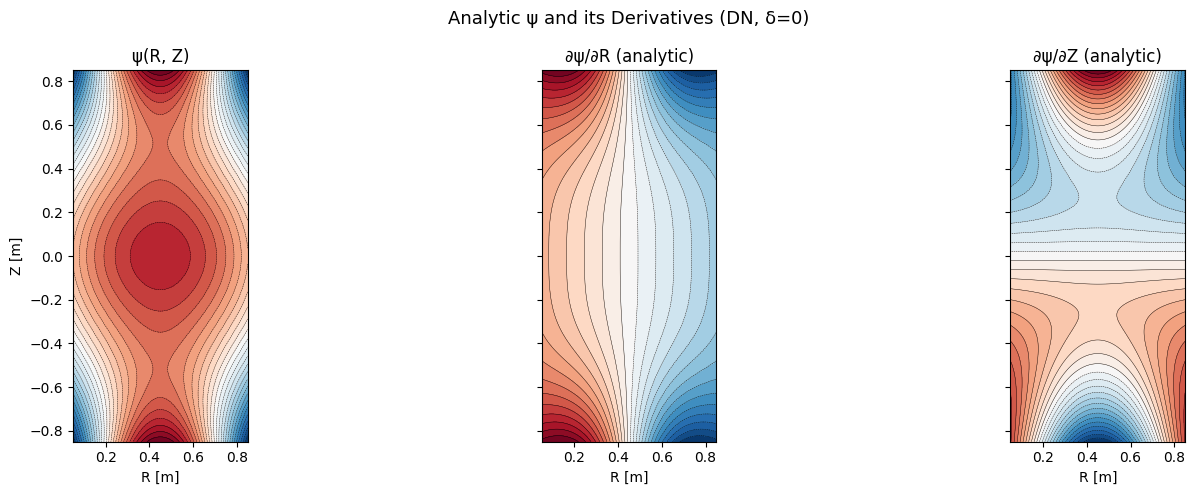

In [242]:
# --- Plot analytic derivatives for DN case ---
delta: float = 0.0

psi: np.ndarray = psi_analytic(r_2d, z_2d, **common_kwargs, delta=delta)
dpsi_dr: np.ndarray = dpsi_dr_analytic(r_2d, z_2d, **common_kwargs, delta=delta)
dpsi_dz: np.ndarray = dpsi_dz_analytic(r_2d, z_2d, **common_kwargs, delta=delta)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, data, title in zip(
    axes,
    [psi, dpsi_dr, dpsi_dz],
    ["ψ(R, Z)", "∂ψ/∂R (analytic)", "∂ψ/∂Z (analytic)"],
):
    n_levels: int = 30
    levels: np.ndarray = np.linspace(data.min(), data.max(), n_levels)
    ax.contourf(r_2d, z_2d, data, levels=levels, cmap="RdBu_r")
    ax.contour(r_2d, z_2d, data, levels=levels, colors="k", linewidths=0.3)
    ax.set_title(title)
    ax.set_xlabel("R [m]")
    ax.set_aspect("equal")

axes[0].set_ylabel("Z [m]")
fig.suptitle("Analytic ψ and its Derivatives (DN, δ=0)", fontsize=13)
fig.tight_layout()
plt.show()

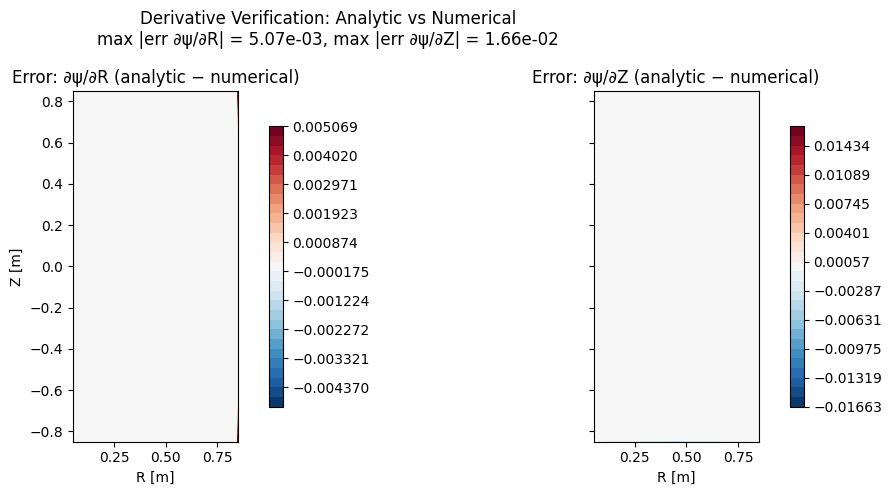

In [243]:
# --- Verify analytic derivatives against numerical finite differences ---
delta: float = 0.0

psi: np.ndarray = psi_analytic(r_2d, z_2d, **common_kwargs, delta=delta)
dpsi_dr_ana: np.ndarray = dpsi_dr_analytic(r_2d, z_2d, **common_kwargs, delta=delta)
dpsi_dz_ana: np.ndarray = dpsi_dz_analytic(r_2d, z_2d, **common_kwargs, delta=delta)

# Numerical derivatives via central differences
dr: float = r_1d[1] - r_1d[0]
dz: float = z_1d[1] - z_1d[0]
dpsi_dr_num: np.ndarray = np.gradient(psi, dr, axis=1)
dpsi_dz_num: np.ndarray = np.gradient(psi, dz, axis=0)

# Errors
err_dr: np.ndarray = dpsi_dr_ana - dpsi_dr_num
err_dz: np.ndarray = dpsi_dz_ana - dpsi_dz_num

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, err, title in zip(
    axes,
    [err_dr, err_dz],
    ["Error: ∂ψ/∂R (analytic − numerical)", "Error: ∂ψ/∂Z (analytic − numerical)"],
):
    n_levels: int = 30
    levels: np.ndarray = np.linspace(err.min(), err.max(), n_levels)
    im = ax.contourf(r_2d, z_2d, err, levels=levels, cmap="RdBu_r")
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title)
    ax.set_xlabel("R [m]")
    ax.set_aspect("equal")

axes[0].set_ylabel("Z [m]")
fig.suptitle(
    f"Derivative Verification: Analytic vs Numerical\nmax |err ∂ψ/∂R| = {np.max(np.abs(err_dr)):.2e}, max |err ∂ψ/∂Z| = {np.max(np.abs(err_dz)):.2e}",
    fontsize=12,
)
fig.tight_layout()
plt.show()

In [244]:
# --- Analytically find and classify stationary points ---

def find_stationary_points(
    mag_r: float, mag_z: float, psi_0: float, delta: float, s: float = 1.3
) -> list[dict]:
    """Find all stationary points of psi analytically.

    All stationary points lie on R = mag_r (r_hat = 0).
    For z_hat >= 0:  3*z_hat^2 - 2*z_hat - delta/2 = 0
    For z_hat <  0:  3*z_hat^2 + 2*z_hat + delta/2 = 0

    Classification at r_hat = 0:
      psi_RR = -2*psi_0*s^2*(1 + 4*|z_hat|^3)   (always same sign as -psi_0)
      psi_ZZ = -psi_0*s^2*(2 - 6*|z_hat|)
      psi_RZ = 0
      H = psi_RR * psi_ZZ
      |z_hat| < 1/3 -> H > 0, local max (for psi_0 > 0) => magnetic axis
      |z_hat| > 1/3 -> H < 0, saddle point => X-point
    """
    points: list[dict] = []

    # z_hat >= 0 branch: 3*z^2 - 2*z - delta/2 = 0
    disc_pos: float = 1.0 + 1.5 * delta
    if disc_pos >= 0:
        sqrt_dp: float = np.sqrt(disc_pos)
        for sign in [+1, -1]:
            zh: float = (1.0 + sign * sqrt_dp) / 3.0
            if zh >= 0:
                points.append(zh)

    # z_hat < 0 branch: 3*z^2 + 2*z + delta/2 = 0
    disc_neg: float = 1.0 - 1.5 * delta
    if disc_neg >= 0:
        sqrt_dn: float = np.sqrt(disc_neg)
        for sign in [+1, -1]:
            zh: float = (-1.0 + sign * sqrt_dn) / 3.0
            if zh < 0:
                points.append(zh)

    # Build result with classification
    results: list[dict] = []
    for zh in sorted(set(points)):
        r_phys: float = mag_r
        z_phys: float = mag_z + zh / s
        zh2: float = zh + delta / 4.0

        # psi value at r_hat=0
        psi_val: float = -psi_0 * (zh2**2 - np.abs(zh) ** 3)

        # Hessian components at r_hat=0
        psi_rr: float = -2.0 * psi_0 * s**2 * (1.0 + 4.0 * np.abs(zh) ** 3)
        psi_zz: float = -psi_0 * s**2 * (2.0 - 6.0 * np.abs(zh))
        hessian_det: float = psi_rr * psi_zz  # psi_rz = 0

        if hessian_det > 0:
            kind = "maximum" if psi_rr < 0 else "minimum"
        elif hessian_det < 0:
            kind = "saddle"
        else:
            kind = "degenerate"

        results.append(
            dict(R=r_phys, Z=z_phys, z_hat=zh, psi=psi_val, psi_RR=psi_rr, psi_ZZ=psi_zz, H=hessian_det, type=kind)
        )

    return results


# --- Print stationary points for each configuration ---
for delta, label in delta_values:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    pts = find_stationary_points(mag_r, mag_z, psi_0, delta)
    for pt in pts:
        print(
            f"  {pt['type']:>9s}  R={pt['R']:.4f}  Z={pt['Z']:+.4f}  "
            f"ẑ={pt['z_hat']:+.4f}  ψ={pt['psi']:+.4f}  "
            f"ψ_RR={pt['psi_RR']:+.3f}  ψ_ZZ={pt['psi_ZZ']:+.3f}  H={pt['H']:+.3f}"
        )


  Lower Single Null (LSN, δ=+0.15)
     saddle  R=0.4500  Z=-0.4821  ẑ=-0.6268  ψ=-0.1010  ψ_RR=-6.709  ψ_ZZ=+2.976  H=-19.963
    maximum  R=0.4500  Z=-0.0307  ẑ=-0.0399  ψ=+0.0001  ψ_RR=-3.381  ψ_ZZ=-2.976  H=+10.060
     saddle  R=0.4500  Z=+0.5402  ẑ=+0.7023  ψ=-0.2009  ψ_RR=-8.063  ψ_ZZ=+3.741  H=-30.162

  Double Null (DN, δ=0)
     saddle  R=0.4500  Z=-0.5128  ẑ=-0.6667  ψ=-0.1481  ψ_RR=-7.386  ψ_ZZ=+3.380  H=-24.964
    maximum  R=0.4500  Z=+0.0000  ẑ=+0.0000  ψ=-0.0000  ψ_RR=-3.380  ψ_ZZ=-3.380  H=+11.424
     saddle  R=0.4500  Z=+0.5128  ẑ=+0.6667  ψ=-0.1481  ψ_RR=-7.386  ψ_ZZ=+3.380  H=-24.964

  Upper Single Null (USN, δ=−0.15)
     saddle  R=0.4500  Z=-0.5402  ẑ=-0.7023  ψ=-0.2009  ψ_RR=-8.063  ψ_ZZ=+3.741  H=-30.162
    maximum  R=0.4500  Z=+0.0307  ẑ=+0.0399  ψ=+0.0001  ψ_RR=-3.381  ψ_ZZ=-2.976  H=+10.060
     saddle  R=0.4500  Z=+0.4821  ẑ=+0.6268  ψ=-0.1010  ψ_RR=-6.709  ψ_ZZ=+2.976  H=-19.963


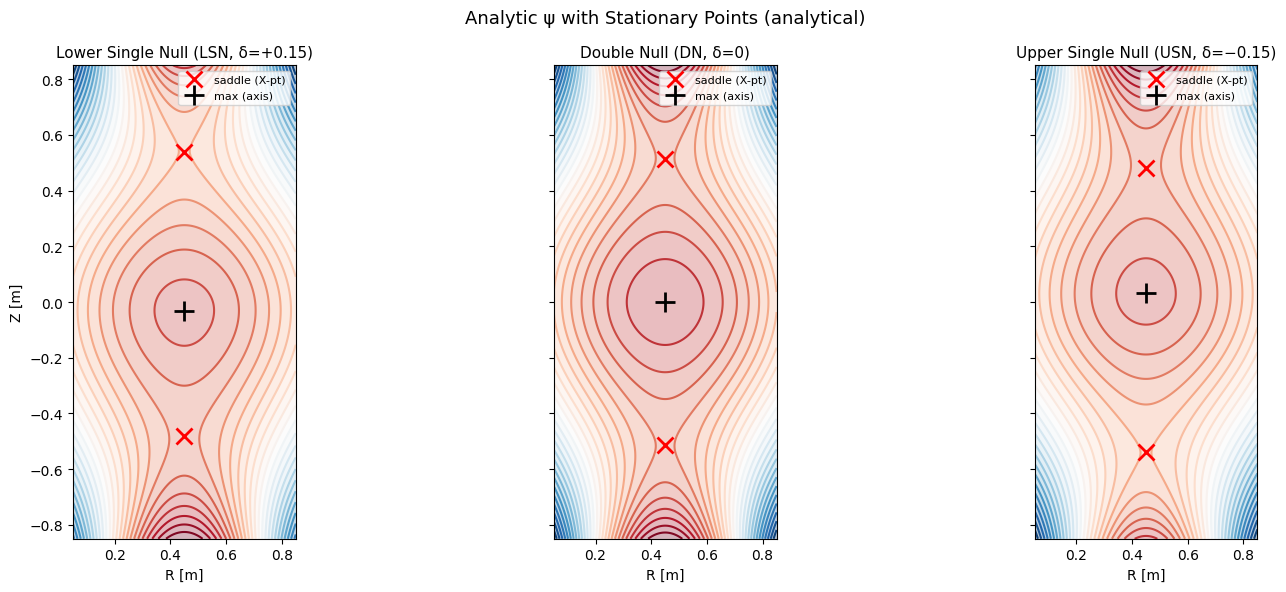

In [245]:
# --- Plot psi with analytically computed stationary points ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for i_delta, (delta, title) in enumerate(delta_values):
    psi: np.ndarray = psi_analytic(r_2d, z_2d, **common_kwargs, delta=delta)
    ax = axes[i_delta]

    n_levels: int = 30
    levels: np.ndarray = np.linspace(psi.min(), psi.max(), n_levels)
    ax.contour(r_2d, z_2d, psi, levels=levels, cmap="RdBu_r")
    ax.contourf(r_2d, z_2d, psi, levels=levels, cmap="RdBu_r", alpha=0.3)

    # Plot analytically computed stationary points
    pts = find_stationary_points(mag_r, mag_z, psi_0, delta)
    for pt in pts:
        if pt["type"] == "maximum":
            ax.plot(pt["R"], pt["Z"], "k+", markersize=14, markeredgewidth=2, label="max (axis)")
        elif pt["type"] == "saddle":
            ax.plot(pt["R"], pt["Z"], "rx", markersize=12, markeredgewidth=2, label="saddle (X-pt)")
        else:
            ax.plot(pt["R"], pt["Z"], "go", markersize=8, label=pt["type"])

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("R [m]")
    if i_delta == 0:
        ax.set_ylabel("Z [m]")
    ax.set_aspect("equal")

    # De-duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8)

fig.suptitle("Analytic ψ with Stationary Points (analytical)", fontsize=13)
fig.tight_layout()
plt.show()